In [7]:
import numpy as np
import pandas as pd

In [8]:
books = pd.read_csv('books.csv')
users = pd.read_csv('users.csv')
ratings = pd.read_csv('ratings.csv')

C:\Users\smrit\AppData\Local\Temp\ipykernel_17604\3819754567.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv('books.csv')


In [9]:
books.head()

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...,http://images.amazon.com/images/P/0393045218.0...


In [10]:
users.head()

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [11]:
ratings.head()

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


In [12]:
print(books.shape)
print(ratings.shape)
print(users.shape)

(271360, 8)
(1149780, 3)
(278858, 3)


In [13]:
# to find the missing values in the data (books.csv) we write this : 
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [14]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [15]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [16]:
# now to find duplicates
books.duplicated().sum()

# if duplicates existed :
# books = books.drop_duplicates()

np.int64(0)

In [17]:
ratings.duplicated().sum()

np.int64(0)

In [18]:
users.duplicated().sum()

np.int64(0)

## Complete EDA Pipeline

1. Understand structure
2. Clean data
3. Analyze columns
4. Visualize data
5. Find insights
6. Prepare for ML

## STEP 1 - Clean Data

What does “cleaning” mean?
Real-world data is messy.

Problems:
- missing values
- wrong datatypes
- duplicate rows
- impossible values
- inconsistent formats

Cleaning means:
fixing these problems before analysis/modeling.

In [19]:
# 1.1 Handle Missing Values
# users.isnull().sum()
# output : Age    110762
# Meaning: many users have no age.
# Why is this a problem?
# Suppose ML model tries: average age
# But half values are missing.
# Then :
# - statistics become wrong 
# - model may crash
# solution : fill missing values
# for numerical columns :
# users['Age'] = users['Age'].fillna(users['Age'].median())
# why median ? 
# suppose ages : 10, 15, 20, 25, 300
# mean becomes huge because of 300
# median stays stable
# so median is safer for real - world data.

In [20]:
# 1.2 Remove Impossible Values
# Now check age statistics:
users['Age'].describe()

count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64

In [21]:
# What are we looking for?
# Impossible ages.
# eg. age = 0 , age = 244
# these are data entry errors.

# Remove unrealistic ages :
# users = users[(users['Age'] >= 5) & (users['Age'] <= 90)]

# Why remove them?
# Because:
# - model learns wrong patterns
# - averages become distorted

In [22]:
# 1.3 Fix Data Types
# Check:
books.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 271360 entries, 0 to 271359
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   ISBN                 271360 non-null  object
 1   Book-Title           271360 non-null  object
 2   Book-Author          271358 non-null  object
 3   Year-Of-Publication  271360 non-null  object
 4   Publisher            271358 non-null  object
 5   Image-URL-S          271360 non-null  object
 6   Image-URL-M          271360 non-null  object
 7   Image-URL-L          271357 non-null  object
dtypes: object(8)
memory usage: 16.6+ MB


In [23]:
# You may see...
# Year-Of-Publication -> object
# But year should be numeric.
# Why dangerous?
# String years cannot:
# - sort correctly
# - calculate statistics
# - work properly in ML

# Convert to numeric
# books['Year-Of-Publication'] = pd.to_numeric(
#     books['Year-Of-Publication'],
#     errors='coerce'
# )

# What does errors='coerce' do?
# Suppose bad value exists:
# "DK Publishing Inc"
# inside year column.

# Python converts it into:
# NaN

# instead of crashing.
# Very useful.

## STEP 2 — Analyze Columns

Column Analysis Means...

For each column ask:

### Question    .................. Example
What type is it?.................. numeric/categorical

How many unique values?............ authors count

Which values are common?............popular ratings

Is distribution balanced?...........rating imbalance

Any strange values?..................age=200

In [24]:
### 2.1 Analyze Numerical Columns
# Example:
# Age
# Book-Rating
# Year-Of-Publication

# Use describe()
users['Age'].describe()

# It shows:
# average age
# min/max age
# spread of ages

count    168096.000000
mean         34.751434
std          14.428097
min           0.000000
25%          24.000000
50%          32.000000
75%          44.000000
max         244.000000
Name: Age, dtype: float64

In [25]:
# 2.2 Analyze Categorical Columns
# Book-Author
# Publisher
# Location

# Use value_counts()
books['Book-Author'].value_counts().head(10)

# It Finds:
# famous authors
# most common publishers

Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64

In [26]:
# 2.3 Check Unique Values
books['Book-Title'].nunique()
# Why?
# Suppose:
# - 2 lakh rows
# - but only 10 unique books
# Then dataset is repetitive.

242135

## STEP 3 — Visualization

Human brain understands graphs faster than tables.

it helps detect :
- patterns
- imbalance
- outliers
- trends
  
instantly

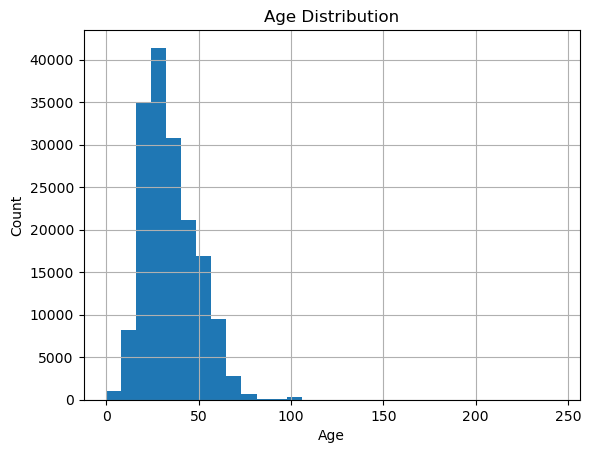

In [27]:
# 3.1 Histogram
# Used for :  numerical data distribution
# Example:
import matplotlib.pyplot as plt

users['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

# What are we looking for?
# Questions:
# Which age group dominates?
# Are children present?
# Are old users many?

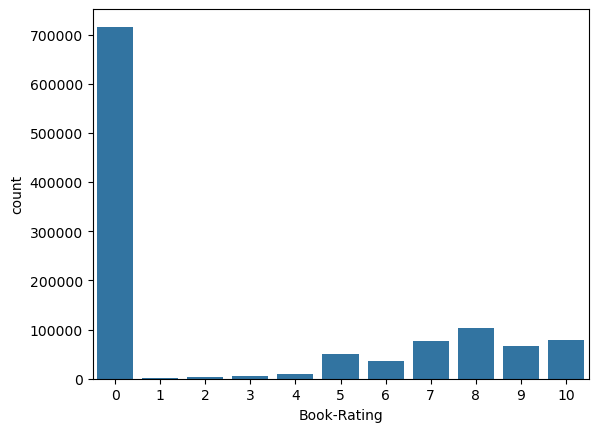

In [28]:
# 3.2 Countplot
# Best for categorical/count data.
# Example:
import seaborn as sns

sns.countplot(x='Book-Rating', data=ratings)
plt.show()

# Here you may discover:
# many ratings are 0
# few people give 10

# Meaning:
# dataset is imbalanced.

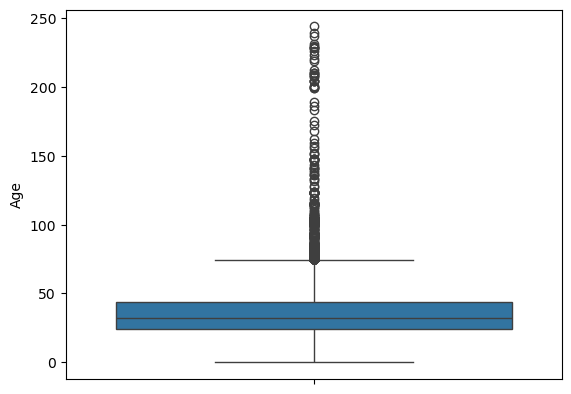

In [29]:
# 3.3 Boxplot
# Used to detect outliers.
sns.boxplot(users['Age'])
plt.show()
# What are outliers?
# Extreme abnormal values.
# Example: age = 200
# Why dangerous?
# Outliers:
# - distort averages
# - confuse ML models

In [30]:
# 3.4 Heatmap
# Used for correlation.
#corr = ratings[['Age', 'Book-Rating']].corr()

#sns.heatmap(corr, annot=True)
#plt.show()

# What is correlation?
# Measures relationship between variables.
# Eg. does age affect ratings ?

## STEP 4 — Find Insights

This is the heart of EDA.

Not code.

Thinking.

Ask Business Questions...

your dataset is about books

so ask : 

In [31]:
# 1. which books are most popular ?
ratings['ISBN'].value_counts().head(10)

ISBN
0971880107    2502
0316666343    1295
0385504209     883
0060928336     732
0312195516     723
044023722X     647
0679781587     639
0142001740     615
067976402X     614
0671027360     586
Name: count, dtype: int64

In [32]:
# 2. which books have highest ratings ?
# df.groupby('Book-Title')['Book-Rating'].mean().sort_values(ascending=False)

In [33]:
# 3. Which country has most users?
users['Country'] = users['Location'].apply(lambda x: x.split(',')[-1])

users['Country'].value_counts().head(10)

Country
 usa               139711
 canada             21658
 united kingdom     18538
 germany            17043
 spain              13147
 australia          11784
 italy              11266
                     4578
 france              3455
 portugal            3325
Name: count, dtype: int64

In [34]:
# 4. Most famous authors?
books['Book-Author'].value_counts().head(10)

Book-Author
Agatha Christie        632
William Shakespeare    567
Stephen King           524
Ann M. Martin          423
Carolyn Keene          373
Francine Pascal        372
Isaac Asimov           330
Nora Roberts           315
Barbara Cartland       307
Charles Dickens        302
Name: count, dtype: int64

In [35]:
# 5. Which books are both popular and highly rated?
# VERY IMPORTANT.
# Because:
# some books have high rating from only 2 users
# not trustworthy

# Combine rating + popularity
#book_stats = df.groupby('Book-Title').agg({
#   'Book-Rating': ['mean', 'count']
#})

#book_stats.columns = ['avg_rating', 'num_ratings']

#popular_books = book_stats[book_stats['num_ratings'] > 200]

#popular_books.sort_values('avg_rating', ascending=False)

# Why this matters?
# this is REAL recommendation logic.
# Netflix/ Amazon also do similar things.

## STEP 5 — Prepare for ML

Now we convert raw data into ML - ready data.

why preparation needed ?

ML models only understand :

- clean
- structured
-  numeric data

5.1 Merge Datasets

Very important.

df = ratings.merge(books, on='ISBN')

df = df.merge(users, on='User-ID')

Why merge?

Now each row contains:

user
book
rating

Together.

ML needs full context.

5.2 Select Useful Features
Not every column helps.

Example:

Image URLs

are useless for collaborative filtering.

Remove unnecessary columns
df = df.drop(['Image-URL-S', 'Image-URL-M', 'Image-URL-L'], axis=1)

5.3 Encode Categorical Data

ML models cannot understand:

Harry Potter
John
India

Need numbers.

Example Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Book-Author'] = le.fit_transform(df['Book-Author'])

5.4 Create Pivot Table

VERY IMPORTANT for recommendation systems.

pivot = df.pivot_table(
    index='Book-Title',
    columns='User-ID',
    values='Book-Rating'
)

What does this create?

Matrix like:

Book...User1.....User2
HP......5........0
LOTR....0........8

Used for:

- cosine similarity
- collaborative filtering

5.5 Fill Missing Ratings

Pivot table has many NaNs.

pivot = pivot.fillna(0)

Why?

ML algorithms usually cannot handle NaN.

## Popularity based recommender system

In [36]:
# now we will merge the ratings and books datasets. Store it in variable name ratings_with_name
ratings_with_name = ratings.merge(books,on='ISBN')

In [37]:
ratings_with_name

,User-ID,ISBN,Book-Rating,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,276725,034545104X,0,Flesh Tones: A Novel,M. J. Rose,2002,Ballantine Books,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...,http://images.amazon.com/images/P/034545104X.0...
1,276726,0155061224,5,Rites of Passage,Judith Rae,2001,Heinle,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...,http://images.amazon.com/images/P/0155061224.0...
2,276727,0446520802,0,The Notebook,Nicholas Sparks,1996,Warner Books,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...,http://images.amazon.com/images/P/0446520802.0...
3,276729,052165615X,3,Help!: Level 1,Philip Prowse,1999,Cambridge University Press,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...,http://images.amazon.com/images/P/052165615X.0...
4,276729,0521795028,6,The Amsterdam Connection : Level 4 (Cambridge ...,Sue Leather,2001,Cambridge University Press,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...,http://images.amazon.com/images/P/0521795028.0...
...,...,...,...,...,...,...,...,...,...,...
1031131,276704,0876044011,0,Edgar Cayce on the Akashic Records: The Book o...,Kevin J. Todeschi,1998,A.R.E. Press (Association of Research &amp; Enlig,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...,http://images.amazon.com/images/P/0876044011.0...
1031132,276704,1563526298,9,Get Clark Smart : The Ultimate Guide for the S...,Clark Howard,2000,Longstreet Press,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...,http://images.amazon.com/images/P/1563526298.0...
1031133,276706,0679447156,0,Eight Weeks to Optimum Health: A Proven Progra...,Andrew Weil,1997,Alfred A. Knopf,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...,http://images.amazon.com/images/P/0679447156.0...
1031134,276709,0515107662,10,The Sherbrooke Bride (Bride Trilogy (Paperback)),Catherine Coulter,1996,Jove Books,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...,http://images.amazon.com/images/P/0515107662.0...


In [38]:
#here we have to calcualte the avg rating of each book and consider only those books
#having total no. of votes > 250

In [39]:
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()
num_rating_df.rename(columns={'Book-Rating':'num_ratings'},inplace=True)
num_rating_df

,Book-Title,num_ratings
0,A Light in the Storm: The Civil War Diary of ...,4
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1
4,Beyond IBM: Leadership Marketing and Finance ...,1
...,...,...
241066,Ã?Â?lpiraten.,2
241067,Ã?Â?rger mit Produkt X. Roman.,4
241068,Ã?Â?sterlich leben.,1
241069,Ã?Â?stlich der Berge.,3


In [40]:
avg_rating_df = ratings_with_name.groupby('Book-Title')['Book-Rating'].agg(lambda x: x.astype(float).mean()).reset_index()
avg_rating_df.rename(columns = {'Book-Rating' : 'avg_rating'}, inplace = True)
avg_rating_df

,Book-Title,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,2.250000
1,Always Have Popsicles,0.000000
2,Apple Magic (The Collector's series),0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,0.000000
...,...,...
241066,Ã?Â?lpiraten.,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,5.250000
241068,Ã?Â?sterlich leben.,7.000000
241069,Ã?Â?stlich der Berge.,2.666667


In [41]:
popular_df = num_rating_df.merge(avg_rating_df,on='Book-Title')
popular_df

,Book-Title,num_ratings,avg_rating
0,A Light in the Storm: The Civil War Diary of ...,4,2.250000
1,Always Have Popsicles,1,0.000000
2,Apple Magic (The Collector's series),1,0.000000
3,"Ask Lily (Young Women of Faith: Lily Series, ...",1,8.000000
4,Beyond IBM: Leadership Marketing and Finance ...,1,0.000000
...,...,...,...
241066,Ã?Â?lpiraten.,2,0.000000
241067,Ã?Â?rger mit Produkt X. Roman.,4,5.250000
241068,Ã?Â?sterlich leben.,1,7.000000
241069,Ã?Â?stlich der Berge.,3,2.666667


In [42]:
popular_df[popular_df['num_ratings']>=250]

,Book-Title,num_ratings,avg_rating
764,1984,284,4.454225
818,1st to Die: A Novel,509,3.575639
1048,2nd Chance,356,3.269663
1760,A Bend in the Road,346,3.364162
2281,"A Child Called \It\"": One Child's Courage to S...",265,4.086792
...,...,...,...
233850,White Oleander : A Novel,387,3.506460
233851,White Oleander : A Novel (Oprah's Book Club),356,3.772472
234740,Wicked: The Life and Times of the Wicked Witch...,326,3.766871
234951,Wild Animus,2502,1.019584


In [51]:
#now we have to sort the avg_rating column in descending order. also we want top 50 books.
#therefore we will write head(50)
popular_df[popular_df['num_ratings']>=250].sort_values('avg_rating',ascending=False).head(50)

,Book-Title,Book-Author,Image-URL-M,num_ratings,avg_rating
89972,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
89954,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
89982,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
89959,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441
89944,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,http://images.amazon.com/images/P/0439064872.0...,556,5.183453
214749,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339681.0...,281,5.007117
209880,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339703.0...,368,4.948370
89989,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...,575,4.895652
237361,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...,260,4.880769
246689,To Kill a Mockingbird,Harper Lee,http://images.amazon.com/images/P/0446310786.0...,510,4.700000


In [57]:
#popular_df = popular_df.merge(books,on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-M','num_ratings','avg_rating']]

In [58]:
popular_df

,Book-Title,Book-Author,Image-URL-M,num_ratings,avg_rating
89972,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
89954,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
89982,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
89959,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441
89944,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,http://images.amazon.com/images/P/0439064872.0...,556,5.183453
214749,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339681.0...,281,5.007117
209880,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339703.0...,368,4.948370
89989,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...,575,4.895652
237361,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...,260,4.880769
246689,To Kill a Mockingbird,Harper Lee,http://images.amazon.com/images/P/0446310786.0...,510,4.700000


In [59]:
popular_df.shape

(50, 5)

In [60]:
popular_df.merge(books,on='Book-Title').columns

Index(['Book-Title', 'Book-Author_x', 'Image-URL-M_x', 'num_ratings',
       'avg_rating', 'ISBN', 'Book-Author_y', 'Year-Of-Publication',
       'Publisher', 'Image-URL-S', 'Image-URL-M_y', 'Image-URL-L'],
      dtype='object')

In [61]:
popular_df.reset_index(drop=True, inplace=True)

In [62]:
popular_df['Image-URL-M'][0]

'http://images.amazon.com/images/P/0439136350.01.MZZZZZZZ.jpg'